# Brain Tumor Segmentation

In [1]:
#import libraires
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import cv2
import pandas as pd
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import CustomObjectScope
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score, accuracy_score


## <font color ='green'> Build U-NET Model 

In [2]:
def conv_block(inputs, num_filters): #two convolutional layers 3x3 
    x = Conv2D(num_filters, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = MaxPool2D((2, 2))(x) #MaxPooling 2x2 stride 2
    return x, p

def decoder_block(inputs, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(inputs) #Upsampling 2x2 stride 2
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def unet(input_shape): #build the model
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="UNET")
    return model

model = unet((256,256,1))
model.summary()

Model: "UNET"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         640       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 256, 256, 64)         0         ['batch_normalization[0][0]

 chNormalization)                                                                                 
                                                                                                  
 activation_8 (Activation)   (None, 16, 16, 1024)         0         ['batch_normalization_8[0][0]'
                                                                    ]                             
                                                                                                  
 conv2d_9 (Conv2D)           (None, 16, 16, 1024)         9438208   ['activation_8[0][0]']        
                                                                                                  
 batch_normalization_9 (Bat  (None, 16, 16, 1024)         4096      ['conv2d_9[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 activatio

 )                                                                   'activation_1[0][0]']        
                                                                                                  
 conv2d_16 (Conv2D)          (None, 256, 256, 64)         73792     ['concatenate_3[0][0]']       
                                                                                                  
 batch_normalization_16 (Ba  (None, 256, 256, 64)         256       ['conv2d_16[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_16 (Activation)  (None, 256, 256, 64)         0         ['batch_normalization_16[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_17

## <font color ='green'> Dice Loss

In [18]:
#Dice coefficient is a measure of overlap between two masks. 
#1 indicates a perfect overlap while 0 indicates no overlap. 
smooth = 1e-15
def dice_coef(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

#Dice Loss = 1 — Dice Coefficient. 
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

## <font color ='green'> Train the model

In [19]:

H = 256
W = 256

def create_dir(path): #to create a file/path
    if not os.path.exists(path):
        os.makedirs(path)
create_dir("files") 

def load_dataset(path, split=0.2): #splitting the data 
    images = sorted(glob(os.path.join(path, "images", "*.png")))
    masks = sorted(glob(os.path.join(path, "masks", "*.png")))

    split_size = int(len(images) * split)

    train_x, valid_x = train_test_split(images, test_size=split_size, random_state=42)
    train_y, valid_y = train_test_split(masks, test_size=split_size, random_state=42)
 
    train_x, test_x = train_test_split(train_x, test_size=split_size, random_state=42)
    train_y, test_y = train_test_split(train_y, test_size=split_size, random_state=42)

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y) 


def read_image(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE) ## (h, w)
    x = cv2.resize(x, (W, H))     ## (h, w)
    x = x / 255.0                 ## (h, w)
    x = x.astype(np.float32)      ## (h, w)
    x = np.expand_dims(x, axis=-1)## (h, w, 1)
    return x

def read_mask(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  ## (h, w)
    x = cv2.resize(x, (W, H))   ## (h, w)
    x = x / 255.0               ## (h, w)
    x = x.astype(np.float32)    ## (h, w)
    x = np.expand_dims(x, axis=-1)## (h, w, 1)
    return x


def tf_parse(x, y):
    def _parse(x, y):
        x = read_image(x)
        y = read_mask(y)
        return x, y

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32]) #function , input , output data type 
    x.set_shape([H, W, 1])
    y.set_shape([H, W, 1])
    return x, y

def tf_dataset(X, Y, batch=2):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y)) #tensorflow input pipeline 
    dataset = dataset.map(tf_parse) #read all images and masks 
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(10)
    return dataset

batch_size = 16
#lr = 1e-4
num_epochs = 70
model_path = os.path.join("files", "model.h5")
csv_path = os.path.join("files", "log.csv") 
dataset_path= r"DataSet"

(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset(dataset_path)

print(f"Train: ({len(train_x)},{len(train_y)})")
print(f"Valid: ({len(valid_x)},{len(valid_x)})")
print(f"Test: ({len(test_x)},{len(test_x)})")

train_dataset = tf_dataset(train_x, train_y, batch=batch_size)
valid_dataset = tf_dataset(valid_x, valid_y, batch=batch_size)


Train: (1840,1840)
Valid: (612,612)
Test: (612,612)


In [5]:

#model = unet((H, W, 1))
model.compile(loss=dice_loss, optimizer='adam', metrics=[dice_coef,'accuracy'])


In [6]:
callbacks = [
        ModelCheckpoint(model_path, verbose=1, save_best_only=True), #save best weights  
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-7, verbose=1), #Reduce the learning rate
        CSVLogger(csv_path), #Save training results
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=False), #Stopping criteria
    ]

In [ ]:
model.fit(
        train_dataset,
        epochs=num_epochs,
        validation_data=valid_dataset,
        callbacks=callbacks,
        verbose=1)

Epoch 1/70
115/115 [==============================] - ETA: 0s - loss: 0.8733 - dice_coef: 0.1267 - accuracy: 0.8353
Epoch 1: val_loss improved from inf to 0.96628, saving model to files/model.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


115/115 [==============================] - 180s 1s/step - loss: 0.8733 - dice_coef: 0.1267 - accuracy: 0.8353 - val_loss: 0.9663 - val_dice_coef: 0.0336 - val_accuracy: 0.0166 - lr: 0.0010
Epoch 2/70
115/115 [==============================] - ETA: 0s - loss: 0.6022 - dice_coef: 0.3978 - accuracy: 0.9779
Epoch 2: val_loss improved from 0.96628 to 0.96051, saving model to files/model.h5
115/115 [==============================] - 111s 968ms/step - loss: 0.6022 - dice_coef: 0.3978 - accuracy: 0.9779 - val_loss: 0.9605 - val_dice_coef: 0.0394 - val_accuracy: 0.2185 - lr: 0.0010
Epoch 3/70
115/115 [==============================] - ETA: 0s - loss: 0.5067 - dice_coef: 0.4933 - accuracy: 0.9829
Epoch 3: val_loss did not improve from 0.96051
115/115 [==============================] - 106s 918ms/step - loss: 0.5067 - dice_coef: 0.4933 - accuracy: 0.9829 - val_loss: 0.9702 - val_dice_coef: 0.0294 - val_accuracy: 0.8679 - lr: 0.0010
Epoch 4/70
115/115 [==============================] - ETA: 0s - l

## <font color ='green'> Learnig curves

In [7]:
metrics = pd.read_csv("files/log.csv")
metrics.head(2)

,epoch,accuracy,dice_coef,loss,lr,val_accuracy,val_dice_coef,val_loss
0,0,0.835296,0.126686,0.873313,0.001,0.016578,0.033641,0.966283
1,1,0.977938,0.397839,0.602161,0.001,0.218519,0.039396,0.960512


## <font color ='green'> Dice_coef

<AxesSubplot:>

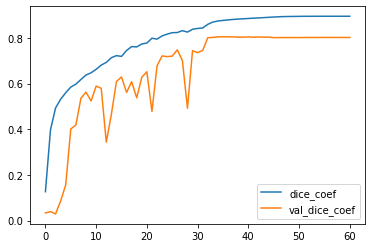

In [8]:
metrics[['dice_coef','val_dice_coef']].plot()

<AxesSubplot:>

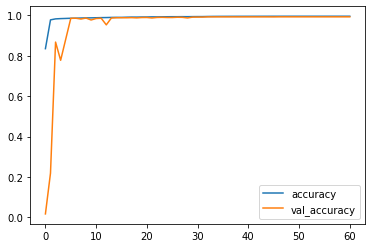

In [9]:
metrics[['accuracy','val_accuracy']].plot()

<AxesSubplot:>

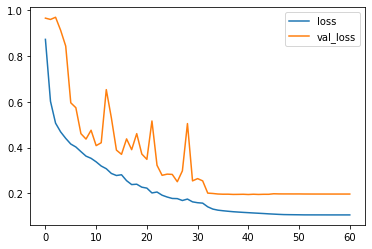

In [10]:
metrics[['loss','val_loss']].plot()

## <font color ='green'>Evaluate the model

In [20]:
def save_results(save_image_path,y_pred):
    y_pred = np.expand_dims(y_pred, axis=-1)
    y_pred = y_pred * 255
    #print("Saving image to:", save_image_path)
    cv2.imwrite(save_image_path, y_pred)


In [25]:

from tqdm import tqdm #progress bar
""" Directory for storing files """
create_dir("predictions")

""" Load the model """
with CustomObjectScope({"dice_coef": dice_coef, "dice_loss": dice_loss}):
        model = tf.keras.models.load_model(os.path.join("files", "model.h5"))

        
""" Dataset """
dataset_path = r"DataSet"
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset(dataset_path)

""" Prediction and Evaluation """
SCORE = []
NAMES = []


for x, y in tqdm(zip(test_x, test_y), total=len(test_y)):
        """ Extracting the name """
        name = x.split("/")[-1]
        #print(name)

        """ Reading the image """
        image = cv2.imread(x, cv2.IMREAD_GRAYSCALE) ## [H, w, 1]
        image = cv2.resize(image, (W, H))       ## [H, w, 1]
        x = image/255.0                         ## [H, w, 1]
        x = np.expand_dims(x, axis=0)           

        """ Reading the mask """
        mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (W, H))
        mask = mask/255.0
        mask = (mask >= 0.5).astype(np.int32)  ##threshold

        """ Prediction """
        y_pred = model.predict(x, verbose=0)[0]
        y_pred = np.squeeze(y_pred, axis=-1)
        y_pred = (y_pred >= 0.5).astype(np.int32)  ##threshold
       

        """ Saving the prediction """
        filename = os.path.basename(name)
        save_image_path = os.path.join(r"predictions", filename) 
        #cv2.imwrite(save_image_path,y_pred)
        save_results(save_image_path,y_pred)
        NAMES.append(filename)

        """ Flatten the array """
        mask = mask.flatten()
        y_pred = y_pred.flatten()

        """ Calculating the metrics values """
        f1_value = f1_score(mask, y_pred, labels=[0, 1], average="binary")
        jac_value = jaccard_score(mask, y_pred, labels=[0, 1], average="binary")
        recall_value = recall_score(mask, y_pred, labels=[0, 1], average="binary", zero_division=0)
        precision_value = precision_score(mask, y_pred, labels=[0, 1], average="binary", zero_division=0)

        
        SCORE.append([name[15:], f1_value, jac_value, recall_value, precision_value])


""" Metrics values """
score = [s[1:]for s in SCORE]
score = np.mean(score, axis=0)
print(f"F1: {score[0]:0.5f}")
print(f"Jaccard: {score[1]:0.5f}")
print(f"Recall: {score[2]:0.5f}")
print(f"Precision: {score[3]:0.5f}")


df = pd.DataFrame(SCORE, columns=["Image", "F1", "Jaccard", "Recall", "Precision"])
df.to_csv("files/score.csv", index=None)

100%|████████████████████████████████████████████████████████████████████████████████| 612/612 [12:46<00:00,  1.25s/it]

F1: 0.73248
Jaccard: 0.64594
Recall: 0.75752
Precision: 0.76914


In [26]:
scores = pd.read_csv("files/score.csv")
scores.head(3)

,Image,F1,Jaccard,Recall,Precision
0,833.png,0.918143,0.848674,0.957746,0.881686
1,2069.png,0.771757,0.628342,1.000000,0.628342
2,3038.png,0.800310,0.667097,0.805296,0.795385


## <font color ='green'> Plot predicted images


In [33]:
def plot_imgs(images_name, ran_num):
    image = cv2.imread("DataSet/images/" + images_name , 0)
    mask = cv2.imread("DataSet/masks/" + images_name,0)
    predict = cv2.imread("predictions/" + images_name,0)

    #plt.imshow(mask)

    image = cv2.resize(image, (256, 256))
    mask = cv2.resize(mask, (256, 256))

    plt.figure(figsize=(20,20))
    plt.subplot(1,3,1), plt.xticks([]), plt.yticks([]),plt.imshow(image, cmap = 'gray')
    plt.title('Brain Image',fontsize=15) 

    plt.subplot(1,3,2), plt.xticks([]), plt.yticks([]),plt.imshow(mask, cmap = 'gray')
    plt.title('Original Mask',fontsize=15)

    plt.subplot(1,3,3), plt.xticks([]), plt.yticks([]),plt.imshow(predict, cmap = 'gray')
    plt.title('Predicted Mask',fontsize=15)

    plt.show()

    image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  

    # Find contours in the mask image
    # Draw contours on the BGR image
    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    combined = cv2.drawContours(image.copy(), contours, -1, (0, 255, 0),thickness=cv2.FILLED)

    
    contours1, _ = cv2.findContours(predict, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    combined1 = cv2.drawContours(image.copy(), contours1, -1, (0, 0, 255),thickness=cv2.FILLED)
    
    
    
    combined_overlap = cv2.drawContours(combined.copy(), contours1, -1, (0, 0, 255),thickness=cv2.FILLED)

    # concatenate image Horizontally 
    combainedMasks = np.concatenate((combined, combined1), axis=1) 

    plt.figure(figsize=(40,40))
    plt.subplot(1,3,3), plt.xticks([]), plt.yticks([])
    plt.title('Original Mask vs Predicted Mask',fontsize=15)
    plt.imshow(combainedMasks)
    plt.show();
    
    
    plt.figure(figsize=(10,10))
    plt.xticks([]), plt.yticks([])
    plt.title('Masks Overlap',fontsize=15)
    plt.imshow(combined_overlap)
    plt.show();

    #cv2.imshow("Original Mask vs Predicted Mask", Hori)
    #cv2.waitKey(0)
    #cv2.destroyAllWindows()

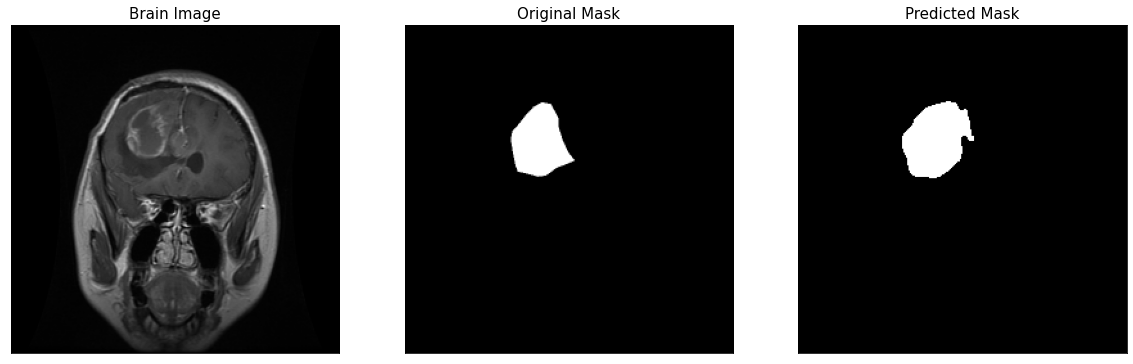

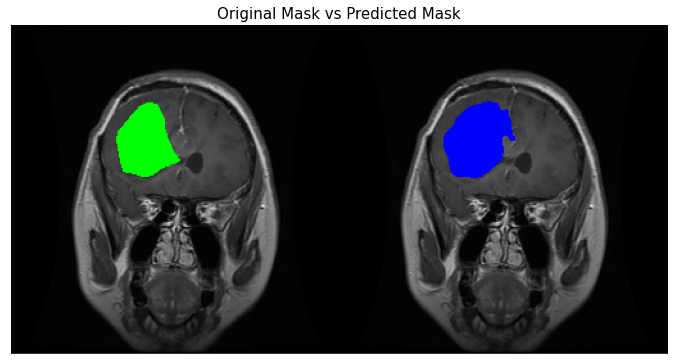

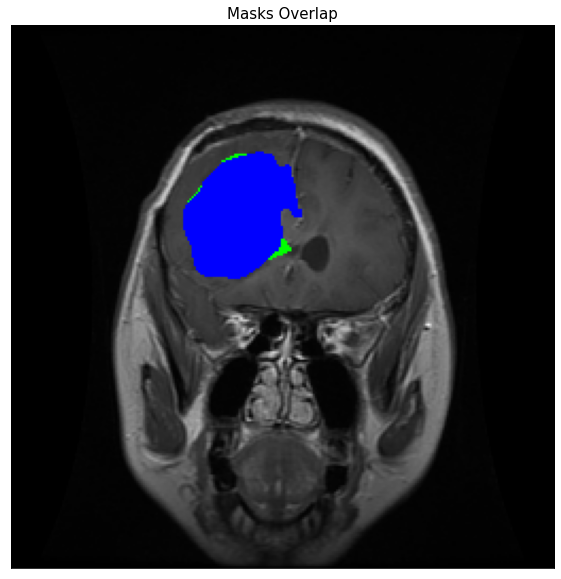

In [37]:
ran_num = random.randint(1, 204)
images_name = NAMES[ran_num]
plot_imgs(images_name, ran_num)

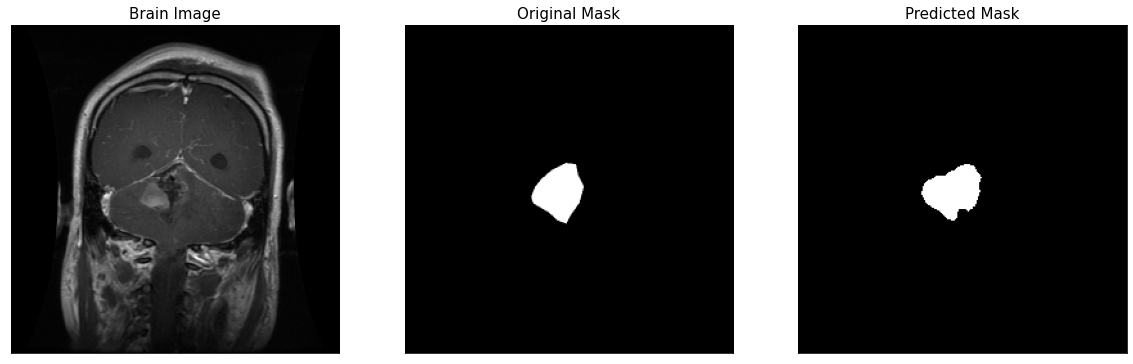

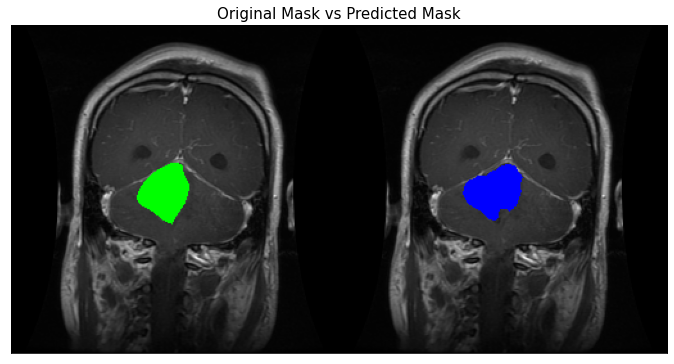

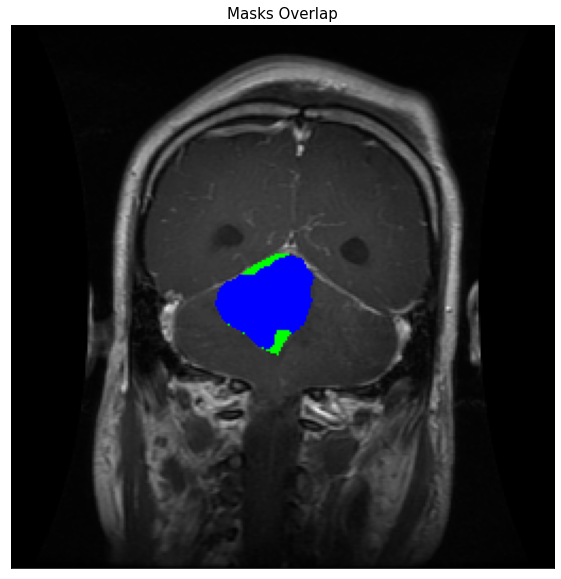

In [38]:
ran_num = random.randint(205, 408)
images_name = NAMES[ran_num]
plot_imgs(images_name, ran_num)

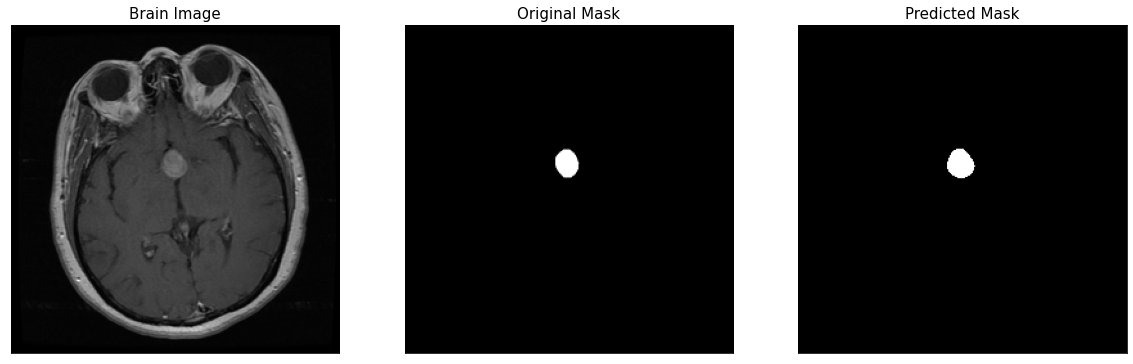

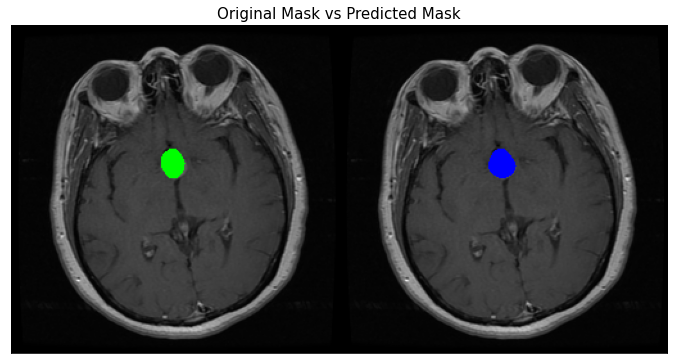

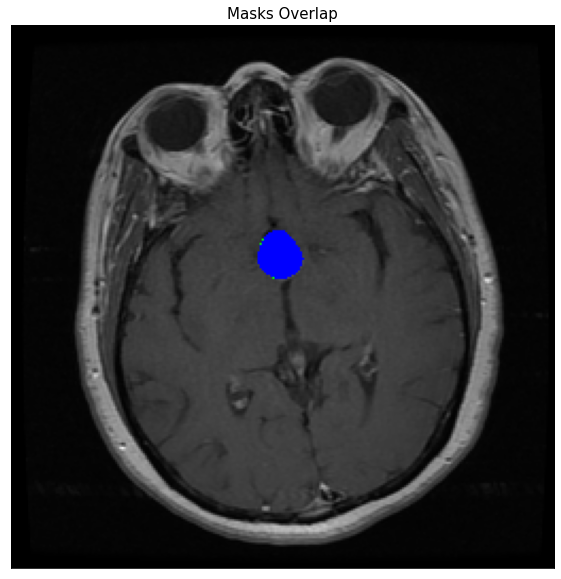

In [39]:
ran_num = random.randint(409, 612)
images_name = NAMES[ran_num]
plot_imgs(images_name, ran_num)